## 0. Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load the Data

In [21]:
df = pd.read_csv("housing.csv")
print("Shape:", df.shape)
df.head()

df.info()

df.describe().T

Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 2. Data Quality Check

In [22]:
# Missing values
df.isnull().sum()

# Duplicated rows
print("Duplicated rows:", df.duplicated().sum())

# Categorical column overview
df["ocean_proximity"].value_counts()

##> **Observation 1:** `total_bedrooms` has missing values (only column affected).  
##> **Observation 2:** `median_house_value` is **capped at 500001** — an important caveat for later interpretation.

Duplicated rows: 0


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 3. Data Wrangling

In [23]:
# 3.1 Handle missing values (median imputation — robust to outliers)
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# 3.2 Remove duplicates (if any)
df = df.drop_duplicates().reset_index(drop=True)

# 3.3 Feature engineering (ratio features are more interpretable than raw counts)
df["rooms_per_household"]      = df["total_rooms"]    / df["households"]
df["bedrooms_ratio"]           = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]     / df["households"]

print("Missing values after cleaning:", df.isnull().sum().sum())
df[["rooms_per_household", "bedrooms_ratio", "population_per_household"]].describe().T

Missing values after cleaning: 0


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
bedrooms_ratio,20640.0,0.213794,0.065248,0.037151,0.175225,0.203159,0.240126,2.824675
population_per_household,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333


## 4. Exploratory Data Analysis

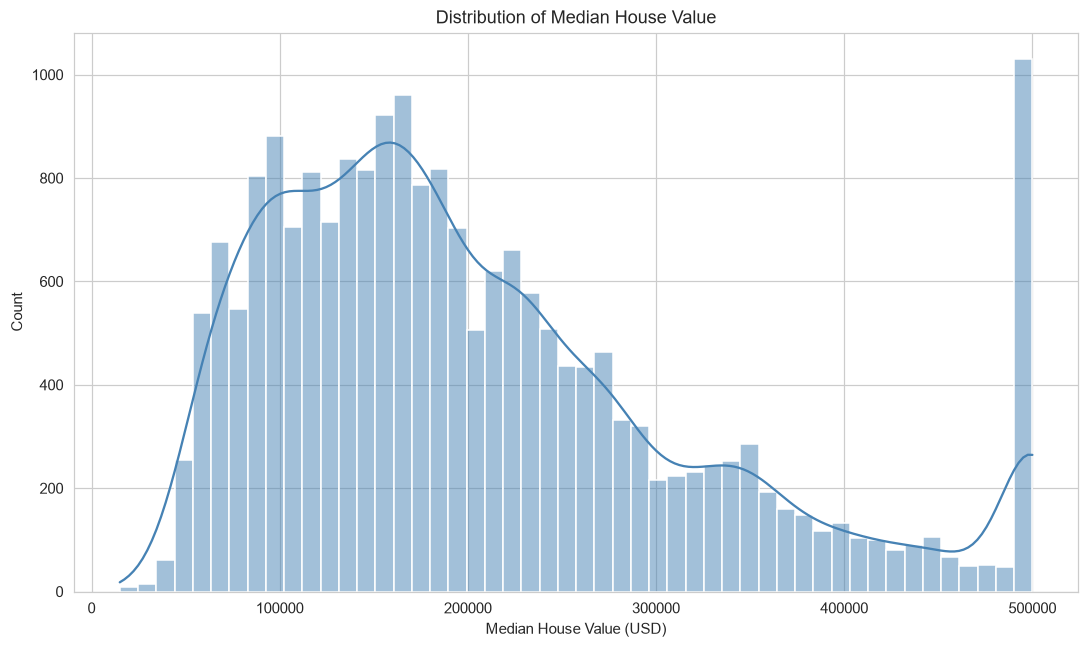

In [24]:
### 4.1 Distribution of the Target Variable

fig, ax = plt.subplots()
sns.histplot(df["median_house_value"], bins=50, kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of Median House Value")
ax.set_xlabel("Median House Value (USD)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

##> Right-skewed distribution with a visible spike at the 500,001 cap.

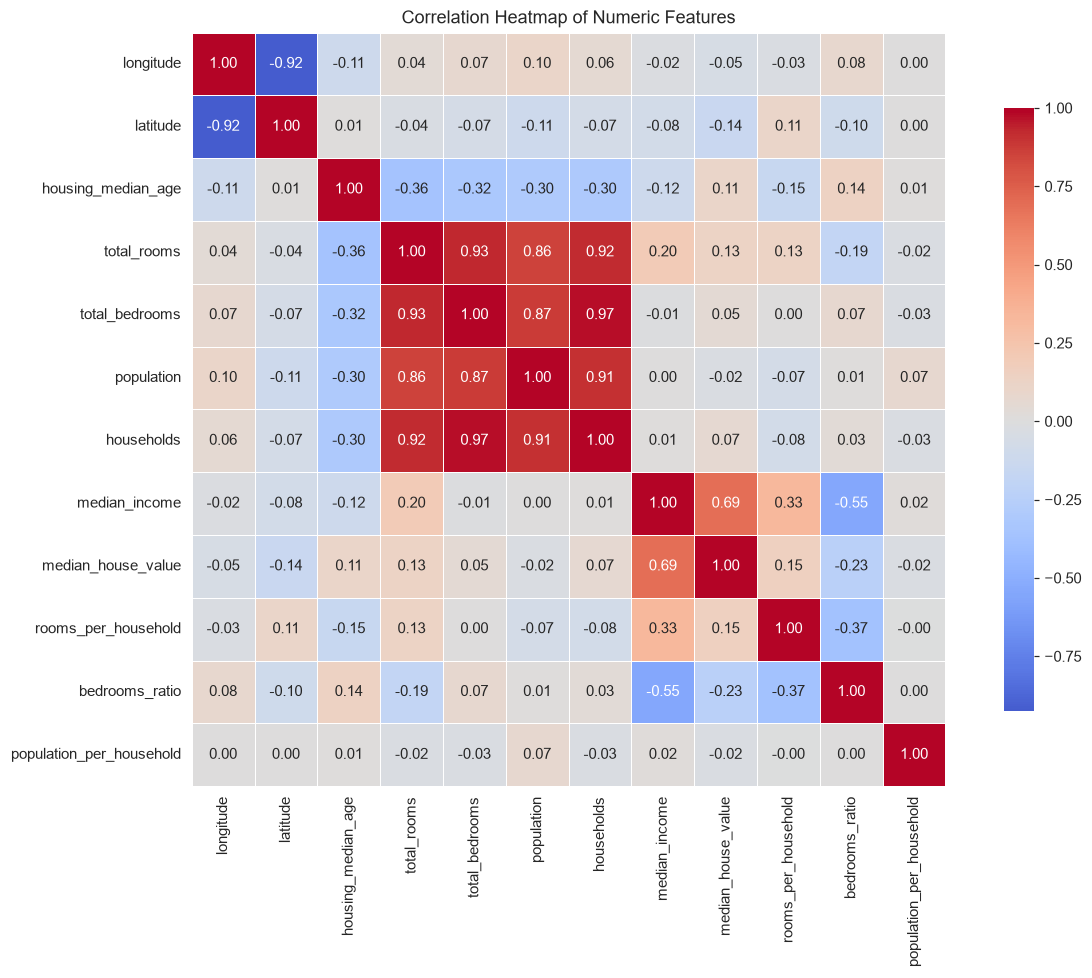

In [25]:
### 4.2 Correlation Matrix (Numeric Features)

num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

# Rank features by correlation with the target
corr["median_house_value"].sort_values(ascending=False)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

##> **Key takeaway:** `median_income` is by far the strongest positive correlate with house value.

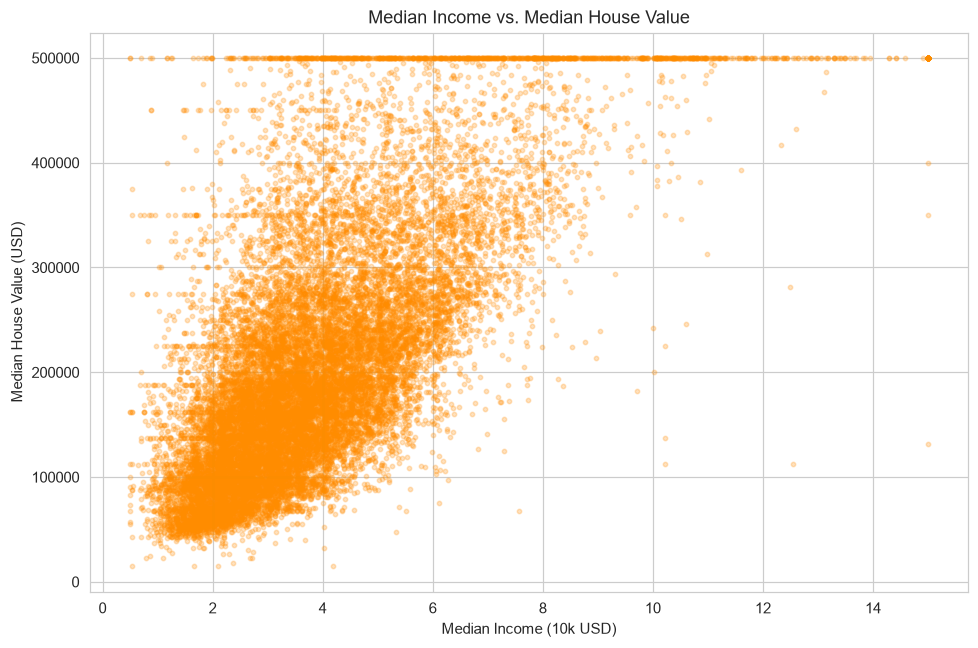

In [26]:
### 4.3 Income vs. House Value (Scatter)

plt.figure(figsize=(9, 6))
plt.scatter(df["median_income"], df["median_house_value"],
            alpha=0.25, s=8, color="darkorange")
plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income (10k USD)")
plt.ylabel("Median House Value (USD)")
plt.tight_layout()
plt.show()

##> Positive but non-linear relationship; horizontal band at 500,001 confirms the cap.

C:\Users\22642\AppData\Local\Temp\ipykernel_97092\4004749146.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ocean_proximity", y="median_house_value",


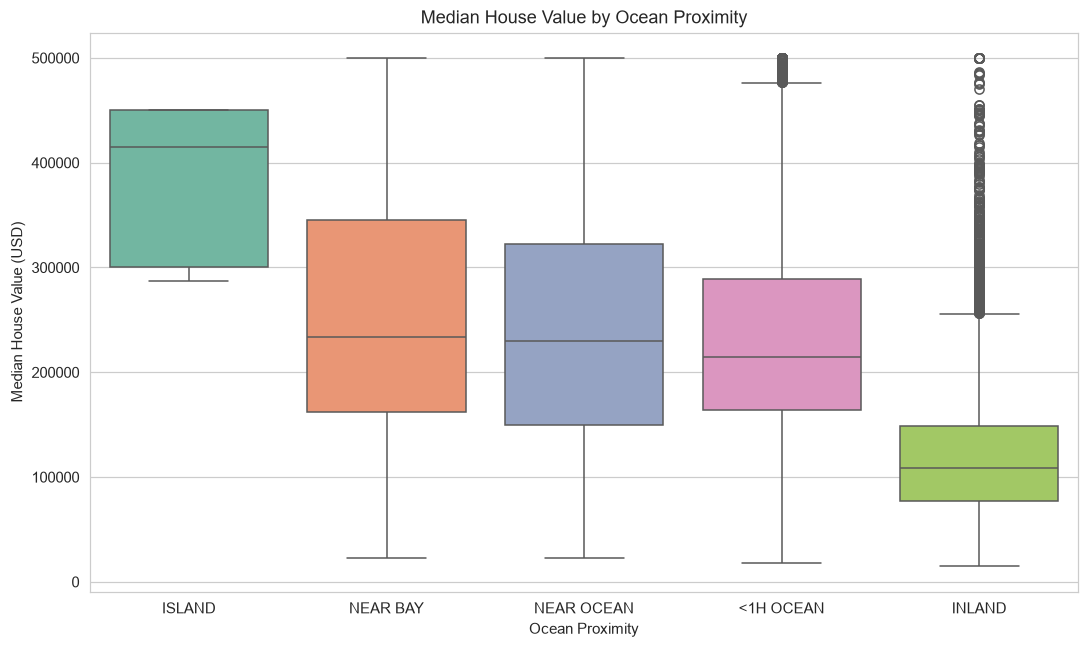

In [27]:
### 4.4 House Value by Ocean Proximity

order = (df.groupby("ocean_proximity")["median_house_value"]
           .median().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value",
            order=order, palette="Set2")
plt.title("Median House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value (USD)")
plt.tight_layout()
plt.show()

##> Coastal locations (`NEAR BAY`, `<1H OCEAN`, `NEAR OCEAN`) clearly out-price `INLAND`.

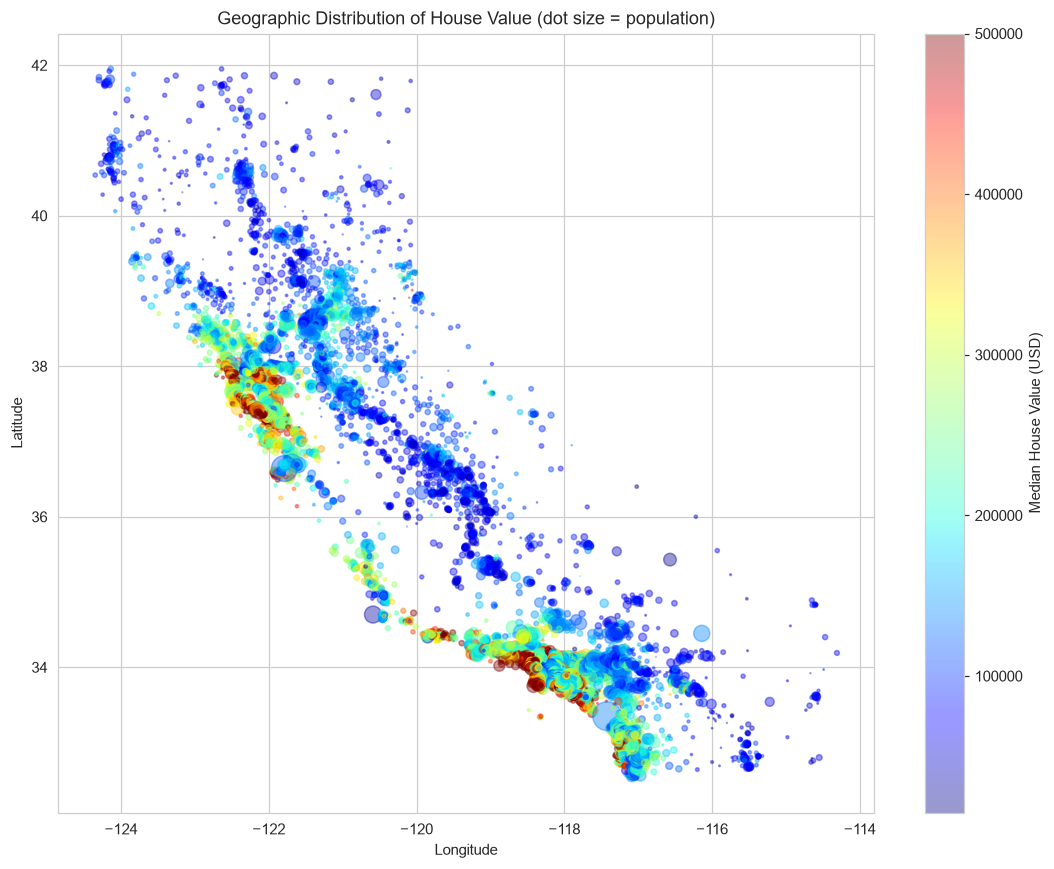

In [28]:
### 4.5 Geographic Distribution (Latitude / Longitude)

plt.figure(figsize=(10, 8))
sc = plt.scatter(df["longitude"], df["latitude"],
                 c=df["median_house_value"], cmap="jet",
                 s=df["population"] / 100, alpha=0.4)
plt.colorbar(sc, label="Median House Value (USD)")
plt.title("Geographic Distribution of House Value (dot size = population)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

##> High-value clusters concentrate along the coast (Bay Area, LA, San Diego).

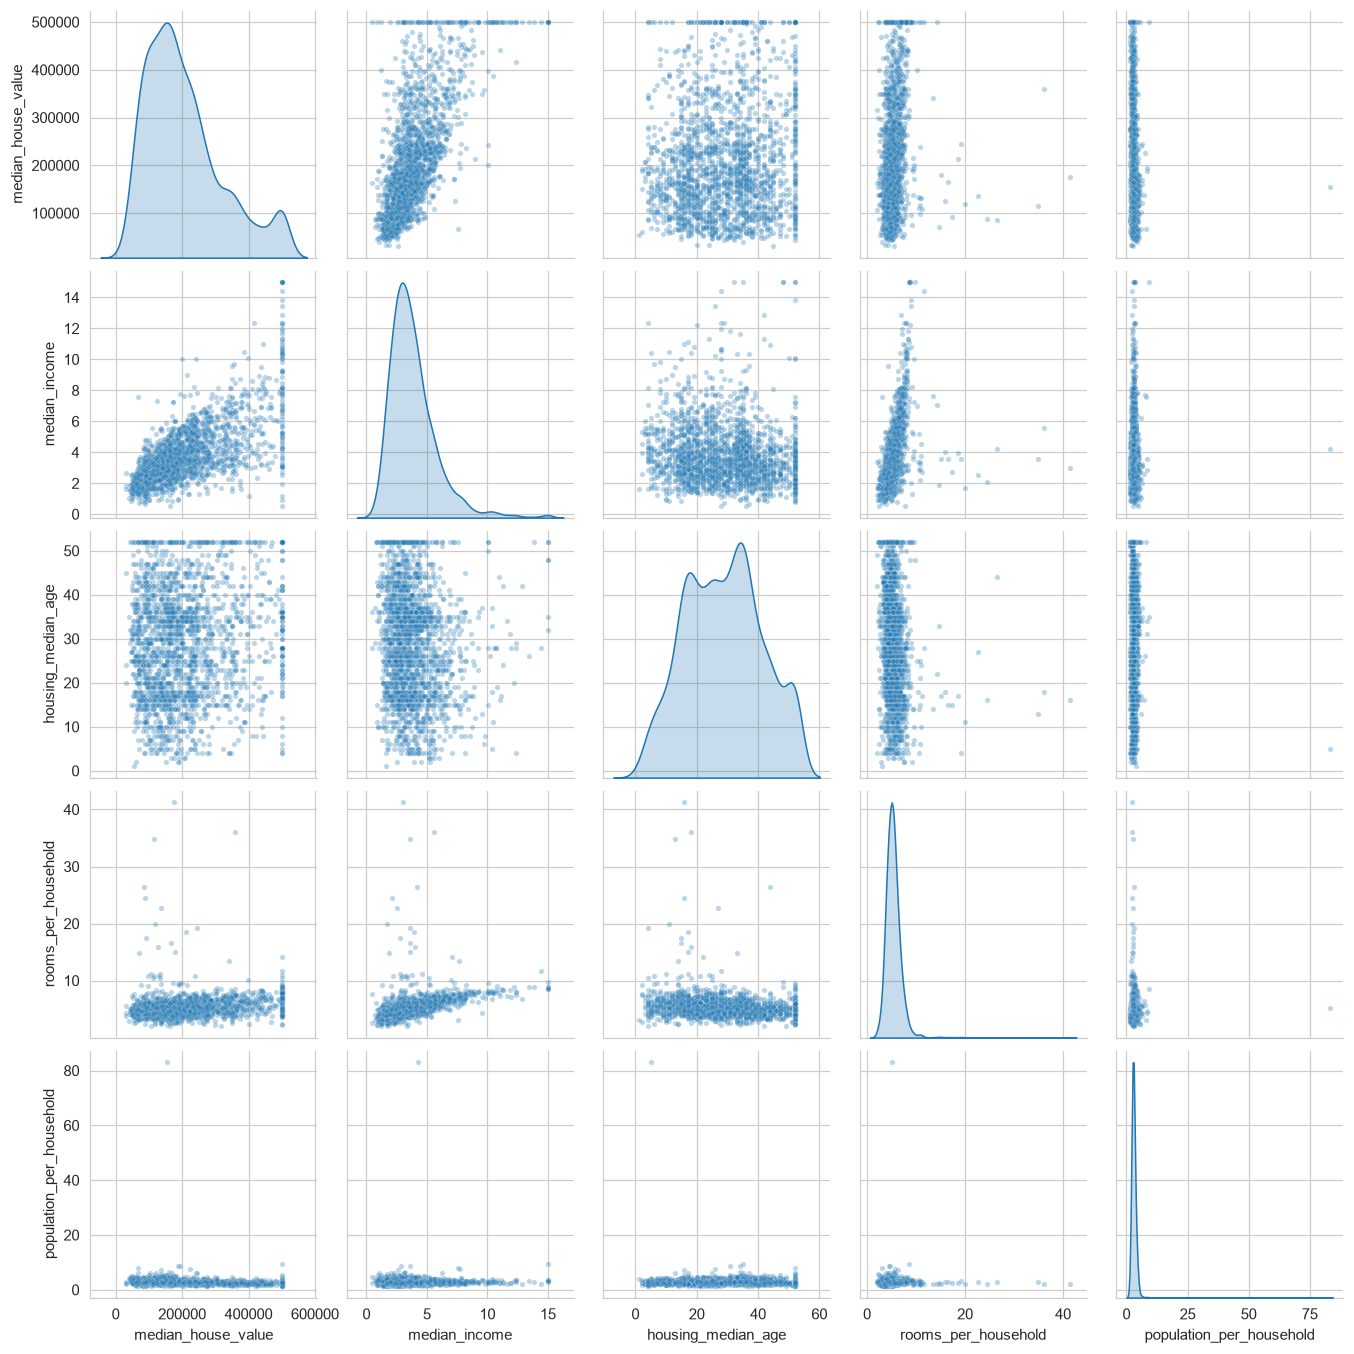

In [29]:
### 4.6 Pairplot of Selected Engineered Features

cols = ["median_house_value", "median_income", "housing_median_age",
        "rooms_per_household", "population_per_household"]

sns.pairplot(df[cols].sample(2000, random_state=42), diag_kind="kde",
             plot_kws={"alpha": 0.3, "s": 12})
plt.show()


## 5. Preliminary Findings (Business Justification)

1. **`median_income` is the dominant driver** (correlation ≈ 0.69) — income level of a neighborhood is the single best predictor of house value.
2. **Location matters enormously.** `ocean_proximity` shows a clear premium for coastal areas, and the geographic scatter reveals tight high-value clusters along the coastline.
3. **Engineered ratio features** (`rooms_per_household`, `population_per_household`) correlate more strongly with price than the raw counts (`total_rooms`, `population`), confirming the value of feature engineering.
4. **Data caveat:** the target is capped at $500,001, which truncates the top of the market and will bias any linear model downward.

**Business implication:** For real estate investment, prioritize neighborhoods by **median income + coastal proximity**, rather than by property age or raw room counts.

## 6. Next Steps

- [ ] Investigate and handle the 500,001 cap (drop vs. keep).
- [ ] Add outlier treatment for `rooms_per_household` / `population_per_household`.
- [ ] Build a simple baseline model (Linear Regression) and compare with a tree-based model.
- [ ] Translate coefficients / feature importances into business recommendations.